In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Downloading data

In [5]:
%cd /content/drive/MyDrive/FRE-GY-7871A-Assignment1/

/content/drive/MyDrive/FRE-GY-7871A-Assignment1


In [ ]:
%run scripts/00_get_lexicons.py

[get ] Loughran-McDonald Master Dictionary
[ok  ] /content/drive/MyDrive/FRE-GY-7871A-Assignment1/data/lexicons/LoughranMcDonald_MasterDictionary.csv (9.1 MB)


In [ ]:
%run scripts/01_build_universe.py

Using frozen snapshot ark_holdings_raw.csv (226 positions, as of ['01/02/2026', '09/04/2026'])
Unique US-listed tickers in the union: 124
  checked 20 tickers...
  checked 40 tickers...
  checked 60 tickers...
  checked 80 tickers...
  checked 120 tickers...

No CIK on file (foreign / private):         7  ['ADYEN', 'ARKY', 'BYDDY', 'HO', 'KMTUY', 'PRNT', 'SE']
CIK found, no 10-K or 10-Q in window:      24
Filers kept:                               93
10-K filings: 416   10-Q filings: 1286   total: 1702

Wrote /content/drive/MyDrive/FRE-GY-7871A-Assignment1/data/universe/universe.csv


In [ ]:
%run scripts/02_download_filings.py

93 filers
[  1/93] ABNB    20 filings (running total 20)
[  2/93] ABSI    18 filings (running total 38)
[  3/93] ACHR    20 filings (running total 58)
[  4/93] ADPT    20 filings (running total 78)
[  5/93] AIR     19 filings (running total 97)
[  6/93] AMD     20 filings (running total 117)
[  7/93] AMZN    20 filings (running total 137)
[  8/93] ARCT    20 filings (running total 157)
[  9/93] AUR     19 filings (running total 176)
[ 10/93] AVAV    20 filings (running total 196)
[ 11/93] AVGO    20 filings (running total 216)
[ 12/93] BEAM    20 filings (running total 236)
[ 13/93] BFLY    20 filings (running total 256)
[ 14/93] BMNR    19 filings (running total 275)
[ 15/93] BWXT    20 filings (running total 295)
[ 16/93] CAT     20 filings (running total 315)
[ 17/93] CDNA    20 filings (running total 335)
[ 18/93] CERS    20 filings (running total 355)
[ 19/93] CMPS    16 filings (running total 371)
[ 20/93] COIN    19 filings (running total 390)
[ 21/93] CRCL     2 filings (runnin

In [ ]:
%run scripts/03_get_market_data.py

96 tickers, 2021-01-01 to 2025-12-31
prices:  1400 days x 96 tickers -> /content/drive/MyDrive/FRE-GY-7871A-Assignment1/data/prices/prices.csv
volume:  1400 days x 96 tickers -> /content/drive/MyDrive/FRE-GY-7871A-Assignment1/data/prices/volume.csv
VIX:     1400 days, mean 19.8 (for the Figure 1 overlay)
  company facts: 20 companies...
  company facts: 40 companies...
  company facts: 60 companies...
  company facts: 80 companies...
shares:  3544 facts -> /content/drive/MyDrive/FRE-GY-7871A-Assignment1/data/prices/shares.csv (96.3% of filings matched)


## Sample Filters

##### Noting that tickers GOOG and GOOGL will have identical accession numbers for SEC filings, therefore the numbers in the output below are 1682 instead of 1702. These will be dropped later in the table.

### Filter 1 Check - Drop amendments (10-K/A, 10-Q/A) and anything that failed to parse.

In [60]:
from pathlib import Path
import pandas as pd

HTML_DIR = Path("data/filings")
TXT_DIR = Path("data/interim/text")
META_PATH = Path("data/interim/filings_meta.csv")

html_accessions = {
    p.stem.replace("-", "")
    for p in HTML_DIR.glob("*.html")
}

txt_accessions = {
    p.name.replace(".txt.gz", "").replace("-", "")
    for p in TXT_DIR.glob("*.txt.gz")
}


meta = pd.read_csv(META_PATH)

meta["accession_clean"] = (
    meta["accession"]
    .astype(str)
    .str.replace("-", "", regex=False)
)

meta_accessions = set(meta["accession_clean"])

print("Raw HTML files:       ", len(html_accessions))
print("Parsed .txt.gz files: ", len(txt_accessions))
print("Rows in metadata:     ", len(meta_accessions))

html_no_txt = html_accessions - txt_accessions
txt_no_meta = txt_accessions - meta_accessions
html_no_meta = html_accessions - meta_accessions

print()
print("HTML but no TXT.GZ:   ", len(html_no_txt))
print("TXT.GZ but no metadata:", len(txt_no_meta))
print("HTML but no metadata: ", len(html_no_meta))

Raw HTML files:        1682
Parsed .txt.gz files:  1682
Rows in metadata:      1682

HTML but no TXT.GZ:    0
TXT.GZ but no metadata: 0
HTML but no metadata:  0


### Filter 2 - At least 2,000 words for a 10-K, 1,000 for a 10-Q.

In [67]:
to_drop = meta[
    ((meta["form"] == "10-K") & (meta["n_words"] < 2000))
    |
    ((meta["form"] == "10-Q") & (meta["n_words"] < 1000))
]

print("Filings to drop:", len(to_drop))

to_drop[["ticker", "form", "filing_date", "n_words", "accession"]]

Filings to drop: 0


,ticker,form,filing_date,n_words,accession


### Filter 3 - One filing per company per calendar quarter, keeping the earliest. If a firm files both 10K/10q in 1 quarter, that earliest filing is kept.

In [69]:
meta["filing_date"] = pd.to_datetime(meta["filing_date"])
meta["calendar_quarter"] = meta["filing_date"].dt.to_period("Q")

fm = meta.sort_values(
    ["cik", "calendar_quarter", "filing_date", "acceptance_datetime"]
).copy()

to_drop_qtr = fm[
    fm.duplicated(
        subset=["cik", "calendar_quarter"],
        keep="first"
    )
]

print("Filings to drop:", len(to_drop_qtr))

to_drop_qtr[
    ["ticker", "cik", "form", "filing_date", "calendar_quarter", "accession"]
]

Filings to drop: 34


,ticker,cik,form,filing_date,calendar_quarter,accession
80,AIR,1750,10-Q,2021-09-23,2021Q3,0001104659-21-118843
84,AIR,1750,10-Q,2022-09-22,2022Q3,0001104659-22-102374
88,AIR,1750,10-Q,2023-09-26,2023Q3,0001104659-23-103944
92,AIR,1750,10-Q,2024-09-24,2024Q3,0001410578-24-001617
94,AIR,1750,10-Q,2025-03-28,2025Q1,0001410578-25-000519
96,AIR,1750,10-Q,2025-09-23,2025Q3,0001104659-25-092589
1556,TRMB,864749,10-Q,2025-01-16,2025Q1,0000864749-25-000013
1557,TRMB,864749,10-Q,2025-01-16,2025Q1,0000864749-25-000014
1559,TRMB,864749,10-Q,2025-05-12,2025Q2,0000864749-25-000113
1124,P,1474432,10-Q,2022-06-16,2022Q2,0001628280-22-017288


In [71]:
prices = pd.read_csv(PRICE_DIR / "prices.csv")

print(prices.columns.tolist())
display(prices.head())

['Date', 'ABNB', 'ABSI', 'ACHR', 'ADPT', 'AIR', 'AMD', 'AMZN', 'ARCT', 'ARKK', 'AUR', 'AVAV', 'AVGO', 'BEAM', 'BFLY', 'BMNR', 'BWXT', 'CAT', 'CDNA', 'CERS', 'CMPS', 'COIN', 'CRCL', 'CRSP', 'CRWD', 'CRWV', 'DASH', 'DDOG', 'DE', 'DKNG', 'FIG', 'FRNM', 'GH', 'GOOG', 'GOOGL', 'GRMN', 'GTLB', 'HEI', 'HON', 'HOOD', 'ICE', 'ILMN', 'INTU', 'IONS', 'IRDM', 'ISRG', 'JOBY', 'KDK', 'KTOS', 'LHX', 'LLY', 'LMT', 'LUNR', 'MASS', 'MELI', 'META', 'NET', 'NFLX', 'NRIX', 'NTLA', 'NTRA', 'NVDA', 'OKLO', 'P', 'PACB', 'PINS', 'PLTR', 'PRME', 'PSNL', 'PYPL', 'QSI', 'RBLX', 'RBRK', 'RKLB', 'ROKU', 'RXRX', 'SDGR', 'SHOP', 'SNOW', 'SNPS', 'SOFI', 'SPY', 'SRTA', 'SYM', 'TDY', 'TEM', 'TER', 'TOST', 'TRMB', 'TSLA', 'TWST', 'TXG', 'VCYT', 'WGS', 'XYZ', 'Z', '^VIX']


,Date,ABNB,ABSI,ACHR,ADPT,AIR,AMD,AMZN,ARCT,ARKK,...,TOST,TRMB,TSLA,TWST,TXG,VCYT,WGS,XYZ,Z,^VIX
0,2020-09-01,NaN,NaN,NaN,41.720001,20.309999,92.180000,174.955994,42.410000,94.110939,...,NaN,53.410000,158.350006,71.720001,113.730003,34.070000,NaN,166.660004,88.440002,26.120001
1,2020-09-02,NaN,NaN,NaN,41.790001,20.520000,90.220001,176.572495,40.650002,93.878586,...,NaN,54.310001,149.123337,70.500000,111.379997,34.160000,NaN,162.880005,89.279999,26.570000
2,2020-09-03,NaN,NaN,NaN,36.740002,20.110001,82.540001,168.399994,38.970001,86.946838,...,NaN,50.900002,135.666672,67.339996,107.769997,32.590000,NaN,152.860001,85.440002,33.599998
3,2020-09-04,NaN,NaN,NaN,35.790001,20.230000,82.010002,164.731003,38.259998,84.274834,...,NaN,49.959999,139.440002,63.270000,106.330002,31.730000,NaN,146.389999,83.879997,30.750000
4,2020-09-08,NaN,NaN,NaN,36.240002,19.590000,78.690002,157.492004,38.630001,80.450760,...,NaN,49.139999,110.070000,62.770000,108.269997,30.700001,NaN,139.110001,80.660004,31.459999


### Filter 5 - A usable day 0, and a price on day -1 of at least $3.

In [74]:
#dropping from the previous filter
filings_meta_qtr = fm.drop_duplicates(
    subset=["cik", "calendar_quarter"],
    keep="first"
).copy()
df = filings_meta_qtr.copy()

#dates
df["filing_date"] = pd.to_datetime(
    df["filing_date"],
    errors="coerce"
)

df["acceptance_datetime"] = pd.to_datetime(
    df["acceptance_datetime"],
    utc=True,
    errors="coerce"
)

prices["Date"] = pd.to_datetime(
    prices["Date"],
    errors="coerce"
)

prices = (
    prices.sort_values("Date")
          .reset_index(drop=True)
)

#find the right acceptance date
df["acceptance_et"] = (
    df["acceptance_datetime"]
      .dt.tz_convert("America/New_York")
)

acceptance_date = (
    df["acceptance_et"]
      .dt.tz_localize(None)
      .dt.normalize()
)

#shift date per instruction according to 4PM ET rule
after_4pm = df["acceptance_et"].dt.hour >= 16

df["acceptance_effective_date"] = (
    acceptance_date
    + pd.to_timedelta(after_4pm.astype(int), unit="D")
)

#day0 candidate - later of filing, acceptance
filing_date_normalized = (
    df["filing_date"]
      .dt.normalize()
)

df["day0_candidate"] = pd.concat(
    [
        filing_date_normalized.rename("filing_date"),
        df["acceptance_effective_date"].rename("acceptance_date")
    ],
    axis=1
).max(axis=1)

#count of filings rolled over
moved = (
    df["day0_candidate"]
    > filing_date_normalized
)

print(
    "Filings moved forward by acceptance-time rule:",
    moved.sum()
)


#day0 day-1 price
def get_day0_info(row):
    ticker = row["ticker"]
    candidate = row["day0_candidate"]

    #missing ticker
    if ticker not in prices.columns:
        return pd.Series({
            "day0": pd.NaT,
            "day_minus1": pd.NaT,
            "price_day_minus1": pd.NA
        })

    #stock price exists
    p = (
        prices[["Date", ticker]]
        .dropna()
        .reset_index(drop=True)
    )

    #day0 coincides with first date
    eligible = p.index[
        p["Date"] >= candidate
    ]

    if len(eligible) == 0:
        return pd.Series({
            "day0": pd.NaT,
            "day_minus1": pd.NaT,
            "price_day_minus1": pd.NA
        })

    i = eligible[0]

    #day-1 does not exist
    if i == 0:
        return pd.Series({
            "day0": p.loc[i, "Date"],
            "day_minus1": pd.NaT,
            "price_day_minus1": pd.NA
        })

    return pd.Series({
        "day0": p.loc[i, "Date"],
        "day_minus1": p.loc[i - 1, "Date"],
        "price_day_minus1": p.loc[i - 1, ticker]
    })


day0_info = df.apply(
    get_day0_info,
    axis=1
)

df = pd.concat(
    [
        df.reset_index(drop=True),
        day0_info.reset_index(drop=True)
    ],
    axis=1
)

#price > 3$ check

to_drop_day0 = df[
    df["day0"].isna()
    | df["price_day_minus1"].isna()
    | (df["price_day_minus1"] < 3)
].copy()

print()
print("Before filter:", len(df))
print("To drop:", len(to_drop_day0))
print("Remaining:", len(df) - len(to_drop_day0))

display(
    to_drop_day0[
        [
            "ticker",
            "form",
            "filing_date",
            "acceptance_et",
            "day0_candidate",
            "day0",
            "day_minus1",
            "price_day_minus1"
        ]
    ]
)

#final filtering

df_day0 = df[
    df["day0"].notna()
    & df["price_day_minus1"].notna()
    & (df["price_day_minus1"] >= 3)
].copy()

Filings moved forward by acceptance-time rule: 948

Before filter: 1668
To drop: 103
Remaining: 1565


,ticker,form,filing_date,acceptance_et,day0_candidate,day0,day_minus1,price_day_minus1
298,CERS,10-K,2023-03-01,2023-03-01 16:24:26-05:00,2023-03-02,2023-03-02,2023-03-01,2.65
299,CERS,10-Q,2023-05-04,2023-05-04 17:09:33-04:00,2023-05-05,2023-05-05,2023-05-04,2.31
300,CERS,10-Q,2023-08-03,2023-08-03 16:24:40-04:00,2023-08-04,2023-08-04,2023-08-03,2.44
301,CERS,10-Q,2023-11-02,2023-11-02 16:53:05-04:00,2023-11-03,2023-11-03,2023-11-02,1.59
302,CERS,10-K,2024-03-05,2024-03-05 16:58:55-05:00,2024-03-06,2024-03-06,2024-03-05,1.99
...,...,...,...,...,...,...,...,...
1621,KDK,10-K,2025-03-12,2025-03-12 17:14:17-04:00,2025-03-13,2025-09-25,NaT,<NA>
1622,KDK,10-Q,2025-05-15,2025-05-15 16:06:27-04:00,2025-05-16,2025-09-25,NaT,<NA>
1623,KDK,10-Q,2025-08-12,2025-08-12 16:29:24-04:00,2025-08-13,2025-09-25,NaT,<NA>
1651,PRME,10-K,2025-02-28,2025-02-28 08:13:01-05:00,2025-02-28,2025-02-28,2025-02-27,2.42


### Filter 6 - At least 60 trading days of returns before day 0 and 60 after.

In [75]:
def count_return_history(row):
    ticker = row["ticker"]
    day0 = row["day0"]

    if ticker not in prices.columns or pd.isna(day0):
        return pd.Series({
            "n_pre_returns": 0,
            "n_post_returns": 0
        })

    p = (
        prices[["Date", ticker]]
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    #returns
    p["return"] = p[ticker].pct_change()

    #count after day0
    n_pre = p.loc[
        (p["Date"] < day0) & p["return"].notna(),
        "return"
    ].count()

    n_post = p.loc[
        (p["Date"] > day0) & p["return"].notna(),
        "return"
    ].count()

    return pd.Series({
        "n_pre_returns": n_pre,
        "n_post_returns": n_post
    })

return_history = df_day0.apply(
    count_return_history,
    axis=1
)

df_day0 = pd.concat(
    [
        df_day0.reset_index(drop=True),
        return_history.reset_index(drop=True)
    ],
    axis=1
)

#60/60 req
to_drop_history = df_day0[
    (df_day0["n_pre_returns"] < 60)
    | (df_day0["n_post_returns"] < 60)
].copy()

print("Before filter:", len(df_day0))
print("To drop:", len(to_drop_history))
print("Remaining:", len(df_day0) - len(to_drop_history))

display(
    to_drop_history[
        [
            "ticker",
            "form",
            "filing_date",
            "day0",
            "n_pre_returns",
            "n_post_returns"
        ]
    ]
)

#final sampling
final_sample = df_day0[
    (df_day0["n_pre_returns"] >= 60)
    & (df_day0["n_post_returns"] >= 60)
].copy()

Before filter: 1565
To drop: 23
Remaining: 1542


,ticker,form,filing_date,day0,n_pre_returns,n_post_returns
491,RBLX,10-Q,2021-05-13,2021-05-13,44,1224
860,ABNB,10-K,2021-02-26,2021-03-01,52,1276
940,FIG,10-Q,2025-09-03,2025-09-04,23,142
966,RXRX,10-Q,2021-05-12,2021-05-12,17,1225
1065,TOST,10-Q,2021-11-09,2021-11-10,34,1098
1122,GTLB,10-Q,2021-12-07,2021-12-07,36,1080
1138,ABSI,10-Q,2021-09-07,2021-09-07,31,1144
1170,COIN,10-Q,2021-05-14,2021-05-14,21,1223
1189,TEM,10-Q,2024-08-06,2024-08-07,35,411
1255,CRWV,10-Q,2025-05-15,2025-05-15,32,218


In [76]:
final_sample.to_csv('outputs/final_sample_interim.csv')

## Words counts, and scoring filings

### 1. Building LM dictionary sentiment words

In [79]:
LM_PATH = "data/lexicons/LoughranMcDonald_MasterDictionary.csv"

lm = pd.read_csv(LM_PATH)

lm.columns = [c.strip() for c in lm.columns]

lm["Word"] = lm["Word"].astype(str).str.upper()

negative_words = set(
    lm.loc[lm["Negative"] > 0, "Word"]
)

uncertainty_words = set(
    lm.loc[lm["Uncertainty"] > 0, "Word"]
)

print("Negative words:", len(negative_words))
print("Uncertainty words:", len(uncertainty_words))

Negative words: 2345
Uncertainty words: 297


In [81]:
final_sample = pd.read_csv('outputs/final_sample_interim.csv',index_col=0)

### 2. Tokenize, counts

In [88]:
import gzip
import re

TOKEN_RE = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def read_filing_text(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8", errors="ignore") as f:
            return f.read()
    else:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()


def get_word_counts(path):
    text = read_filing_text(path)

    tokens = [
        token.upper()
        for token in TOKEN_RE.findall(text)
        if len(token) >= 2
    ]

    return Counter(tokens)

filing_counts = []

for i, row in final_sample.iterrows():
    counts = get_word_counts(row["text_path"])

    filing_counts.append(counts)

    print("Filings processed:", len(filing_counts))

Filings processed: 1
Filings processed: 2
Filings processed: 3
Filings processed: 4
Filings processed: 5
Filings processed: 6
Filings processed: 7
Filings processed: 8
Filings processed: 9
Filings processed: 10
Filings processed: 11
Filings processed: 12
Filings processed: 13
Filings processed: 14
Filings processed: 15
Filings processed: 16
Filings processed: 17
Filings processed: 18
Filings processed: 19
Filings processed: 20
Filings processed: 21
Filings processed: 22
Filings processed: 23
Filings processed: 24
Filings processed: 25
Filings processed: 26
Filings processed: 27
Filings processed: 28
Filings processed: 29
Filings processed: 30
Filings processed: 31
Filings processed: 32
Filings processed: 33
Filings processed: 34
Filings processed: 35
Filings processed: 36
Filings processed: 37
Filings processed: 38
Filings processed: 39
Filings processed: 40
Filings processed: 41
Filings processed: 42
Filings processed: 43
Filings processed: 44
Filings processed: 45
Filings processed: 

### 3. Scoring across filings

In [98]:
import math
from collections import Counter

N = len(filing_counts)

doc_freq = Counter()
positive_words = set(
    lm.loc[lm["Positive"] > 0, "Word"]
)

for counts in filing_counts:
    for word in counts.keys():
        doc_freq[word] += 1


def score_filing(counts, category_words):
    total_words = sum(counts.values())
    distinct_words = len(counts)

    if total_words == 0 or distinct_words == 0:
        return pd.Series({
            "prop": float("nan"),
            "tfidf": float("nan")
        })


    #prop
    category_count = sum(
        counts[word]
        for word in category_words
        if word in counts
    )

    prop = category_count / total_words

    #tfidf

    a_j = total_words / distinct_words

    tfidf = 0.0

    for word in category_words:

        tf = counts.get(word, 0)

        if tf == 0:
            continue

        df_i = doc_freq[word]

        weight = (
            (1 + math.log(tf))
            / (1 + math.log(a_j))
        ) * math.log(N / df_i)

        tfidf += weight

    return pd.Series({
        "prop": prop,
        "tfidf": tfidf
    })


scores = []

for counts in filing_counts:

    neg = score_filing(
        counts,
        negative_words
    )

    pos = score_filing(
        counts,
        positive_words
    )

    unc = score_filing(
        counts,
        uncertainty_words
    )

    scores.append({
        "negative_prop": neg["prop"],
        "negative_tfidf": neg["tfidf"],

        "positive_prop": pos["prop"],
        "positive_tfidf": pos["tfidf"],

        "uncertainty_prop": unc["prop"],
        "uncertainty_tfidf": unc["tfidf"]
    })


scores = pd.DataFrame(scores)

scored_sample = pd.concat(
    [
        final_sample.reset_index(drop=True),
        scores
    ],
    axis=1
)

display(
    scored_sample[
        [
            "ticker",
            "form",
            "filing_date",
            "negative_prop",
            "negative_tfidf",
            "positive_prop",
            "positive_tfidf",
            "uncertainty_prop",
            "uncertainty_tfidf"
        ]
    ].head()
)

Positive words: 347


,ticker,form,filing_date,negative_prop,negative_tfidf,positive_prop,positive_tfidf,uncertainty_prop,uncertainty_tfidf
0,AIR,10-Q,2021-03-23,0.012341,11.512797,0.003303,3.666305,0.011646,8.044230
1,AIR,10-K,2021-07-21,0.020950,89.385490,0.004771,16.057441,0.019172,14.444424
2,AIR,10-Q,2021-12-21,0.011821,7.207912,0.002823,2.793945,0.011644,6.161720
3,AIR,10-Q,2022-03-22,0.010742,7.550941,0.002518,2.781531,0.011413,6.718028
4,AIR,10-K,2022-07-21,0.020373,89.496639,0.005348,18.367527,0.018972,14.290449


### 4. TF.IDF implementation check

In [91]:
test_docs = [
    Counter(["LOSS", "LOSS", "RISK", "GAIN"]),
    Counter(["LOSS", "GAIN", "GAIN"]),
    Counter(["RISK", "RISK", "RISK", "GAIN"])
]

test_word_list = {"LOSS", "RISK"}

test_N = 3

test_df = {
    "LOSS": 2,
    "RISK": 2,
    "GAIN": 3
}


def test_tfidf(counts):
    total_words = sum(counts.values())
    distinct_words = len(counts)

    a_j = total_words / distinct_words

    score = 0

    for word in test_word_list:

        tf = counts.get(word, 0)

        if tf == 0:
            continue

        score += (
            (1 + math.log(tf))
            / (1 + math.log(a_j))
        ) * math.log(
            test_N / test_df[word]
        )

    return score


for i, counts in enumerate(test_docs, start=1):
    print(
        f"d{i}: {test_tfidf(counts):.4f}"
    )

d1: 0.8480
d2: 0.2885
d3: 0.5026


In [99]:
scored_sample.to_csv(
    "outputs/scored_sample_interim.csv",
    index=False
)

In [93]:
import pickle

with open("data/interim/filing_counts.pkl", "wb") as f:
    pickle.dump(filing_counts, f)

### 5. Summary stats for positive, negative sentiments and uncertainty

In [100]:
measure_cols = [
    "negative_prop",
    "negative_tfidf",
    "positive_prop",
    "positive_tfidf",
    "uncertainty_prop",
    "uncertainty_tfidf"
]

table2_clean = (
    scored_sample
    .groupby("form")[measure_cols]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .stack(level=0, future_stack=True)
    .reset_index()
    .rename(columns={
        "form": "Report Type",
        "level_1": "Measure",
        "count": "N",
        "mean": "Mean",
        "std": "Std. Dev.",
        "min": "Min",
        "median": "Median",
        "max": "Max"
    })
)

table2_clean["Measure"] = table2_clean["Measure"].replace({
    "negative_prop": "Negative — Proportional",
    "negative_tfidf": "Negative — tf.idf",

    "positive_prop": "Positive — Proportional",
    "positive_tfidf": "Positive — tf.idf",

    "uncertainty_prop": "Uncertainty — Proportional",
    "uncertainty_tfidf": "Uncertainty — tf.idf"
})

table2_clean = table2_clean[
    [
        "Report Type",
        "Measure",
        "N",
        "Mean",
        "Std. Dev.",
        "Min",
        "Median",
        "Max"
    ]
]

display(table2_clean.round(4))

,Report Type,Measure,N,Mean,Std. Dev.,Min,Median,Max
0,10-K,Negative — Proportional,384,0.0248,0.0046,0.0122,0.0251,0.0355
1,10-K,Negative — tf.idf,384,165.5979,60.8563,59.3756,151.4093,342.8588
2,10-K,Positive — Proportional,384,0.0079,0.0021,0.0041,0.0075,0.0147
3,10-K,Positive — tf.idf,384,43.8769,16.8759,15.1204,41.9390,126.6649
4,10-K,Uncertainty — Proportional,384,0.0211,0.0026,0.0142,0.0214,0.0279
5,10-K,Uncertainty — tf.idf,384,27.5542,9.7143,10.2996,26.0349,64.1263
6,10-Q,Negative — Proportional,1158,0.0211,0.0109,0.0032,0.0171,0.0502
7,10-Q,Negative — tf.idf,1158,75.0873,72.4631,2.1300,33.6514,281.7964
8,10-Q,Positive — Proportional,1158,0.0064,0.0025,0.0007,0.0061,0.0154
9,10-Q,Positive — tf.idf,1158,17.2895,12.7984,0.5095,12.9142,59.8652


### 6. Find 30 most common +ve, -ve sentiment words and words of uncertainty

In [ ]:
all_word_counts = Counter()

for counts in filing_counts:
    all_word_counts.update(counts)


def top_30_words(category_words, category_name):

    category_counts = Counter({
        word: count
        for word, count in all_word_counts.items()
        if word in category_words
    })

    category_total = sum(category_counts.values())

    #top30
    table = pd.DataFrame(
        category_counts.most_common(30),
        columns=["Word", "Count"]
    )

    table["Share (%)"] = (
        table["Count"] / category_total * 100
    )

    table["List"] = category_name

    return table[
        ["List", "Word", "Count", "Share (%)"]
    ]


top_negative = top_30_words(
    negative_words,
    "Negative"
)

top_positive = top_30_words(
    positive_words,
    "Positive"
)

top_uncertainty = top_30_words(
    uncertainty_words,
    "Uncertainty"
)


In [102]:
table3_report = pd.DataFrame({
    "Negative Word": top_negative["Word"].values,
    "Negative Share (%)": top_negative["Share (%)"].values,

    "Positive Word": top_positive["Word"].values,
    "Positive Share (%)": top_positive["Share (%)"].values,

    "Uncertainty Word": top_uncertainty["Word"].values,
    "Uncertainty Share (%)": top_uncertainty["Share (%)"].values
})

display(table3_report.round(3))

,Negative Word,Negative Share (%),Positive Word,Positive Share (%),Uncertainty Word,Uncertainty Share (%)
0,LOSS,4.853,ABLE,9.107,MAY,37.373
1,ADVERSELY,4.792,SUCCESSFULLY,4.747,COULD,20.655
2,ADVERSE,2.956,SUCCESSFUL,4.093,RISK,5.040
3,CLAIMS,2.763,SUCCESS,3.685,RISKS,4.990
4,HARM,2.199,ACHIEVE,3.538,BELIEVE,3.140
5,AGAINST,2.185,COLLABORATION,3.328,APPROXIMATELY,1.818
6,UNABLE,2.182,FAVORABLE,2.707,ASSUMPTIONS,1.315
7,FAILURE,2.074,PROFITABILITY,2.567,FLUCTUATIONS,1.267
8,LOSSES,1.991,GAIN,2.482,MIGHT,1.249
9,LITIGATION,1.930,COLLABORATORS,2.451,UNCERTAINTIES,1.233


## Trend Calculations

In [103]:
trend_df = scored_sample.copy()

trend_df["filing_date"] = pd.to_datetime(trend_df["filing_date"])

trend_df = trend_df[
    trend_df["filing_date"].dt.year.between(2021, 2025)
].copy()

trend_df["quarter"] = trend_df["filing_date"].dt.to_period("Q")

trend_df["time"] = (
    (trend_df["quarter"].dt.year - 2021) * 4
    + (trend_df["quarter"].dt.quarter - 1)
)

display(
    trend_df[
        ["ticker", "form", "filing_date", "quarter", "time"]
    ].head()
)

,ticker,form,filing_date,quarter,time
0,AIR,10-Q,2021-03-23,2021Q1,0
1,AIR,10-K,2021-07-21,2021Q3,2
2,AIR,10-Q,2021-12-21,2021Q4,3
3,AIR,10-Q,2022-03-22,2022Q1,4
4,AIR,10-K,2022-07-21,2022Q3,6


### 1. Calculating a simple average and plotting it - an aggregate average without controlling for within firm baseline

In [104]:
measure_cols = [
    "negative_prop",
    "negative_tfidf",
    "positive_prop",
    "positive_tfidf",
    "uncertainty_prop",
    "uncertainty_tfidf"
]

quarterly = (
    trend_df
    .groupby(["quarter", "form"])[measure_cols]
    .mean()
    .reset_index()
)

quarterly["quarter_date"] = quarterly["quarter"].dt.to_timestamp()

display(quarterly.head(10))

,quarter,form,negative_prop,negative_tfidf,positive_prop,positive_tfidf,uncertainty_prop,uncertainty_tfidf,quarter_date
0,2021Q1,10-K,0.022425,152.581655,0.007469,40.230780,0.019953,26.957267,2021-01-01
1,2021Q1,10-Q,0.022168,59.364147,0.005115,12.381739,0.019986,10.481438,2021-01-01
2,2021Q2,10-K,0.023687,154.709405,0.008885,54.409991,0.019879,29.651800,2021-04-01
3,2021Q2,10-Q,0.019461,67.613191,0.006065,16.048191,0.019242,12.406101,2021-04-01
4,2021Q3,10-K,0.020991,99.683709,0.005525,25.867891,0.019068,17.911952,2021-07-01
5,2021Q3,10-Q,0.020954,77.233118,0.006469,17.962106,0.019317,13.515594,2021-07-01
6,2021Q4,10-K,0.021114,112.737272,0.006567,32.750568,0.019266,18.918971,2021-10-01
7,2021Q4,10-Q,0.021852,83.464934,0.006631,19.155402,0.019705,14.526357,2021-10-01
8,2022Q1,10-K,0.024505,173.054907,0.008090,46.644247,0.021015,30.208283,2022-01-01
9,2022Q1,10-Q,0.022753,60.448140,0.005342,12.668365,0.020012,10.232589,2022-01-01


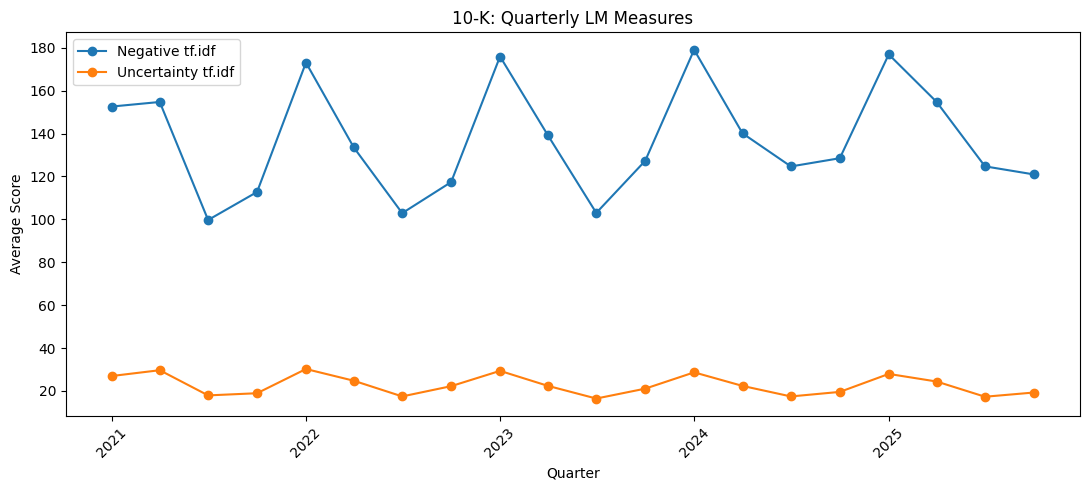

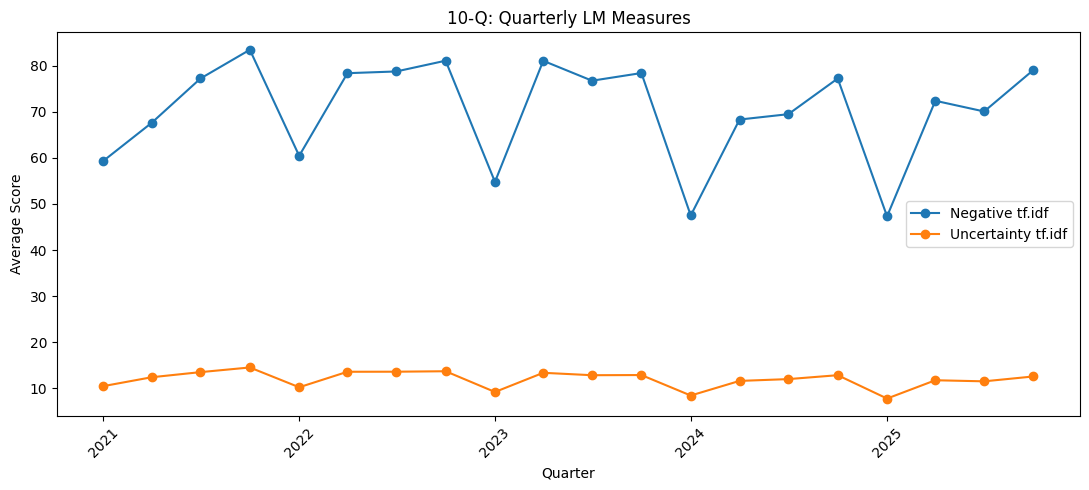

In [105]:
import matplotlib.pyplot as plt

for form in ["10-K", "10-Q"]:

    plot_df = quarterly[
        quarterly["form"] == form
    ].sort_values("quarter_date")

    plt.figure(figsize=(11, 5))

    plt.plot(
        plot_df["quarter_date"],
        plot_df["negative_tfidf"],
        marker="o",
        label="Negative tf.idf"
    )

    plt.plot(
        plot_df["quarter_date"],
        plot_df["uncertainty_tfidf"],
        marker="o",
        label="Uncertainty tf.idf"
    )

    plt.title(f"{form}: Quarterly LM Measures")
    plt.xlabel("Quarter")
    plt.ylabel("Average Score")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2. Plotting VIX with aggregate average measures.

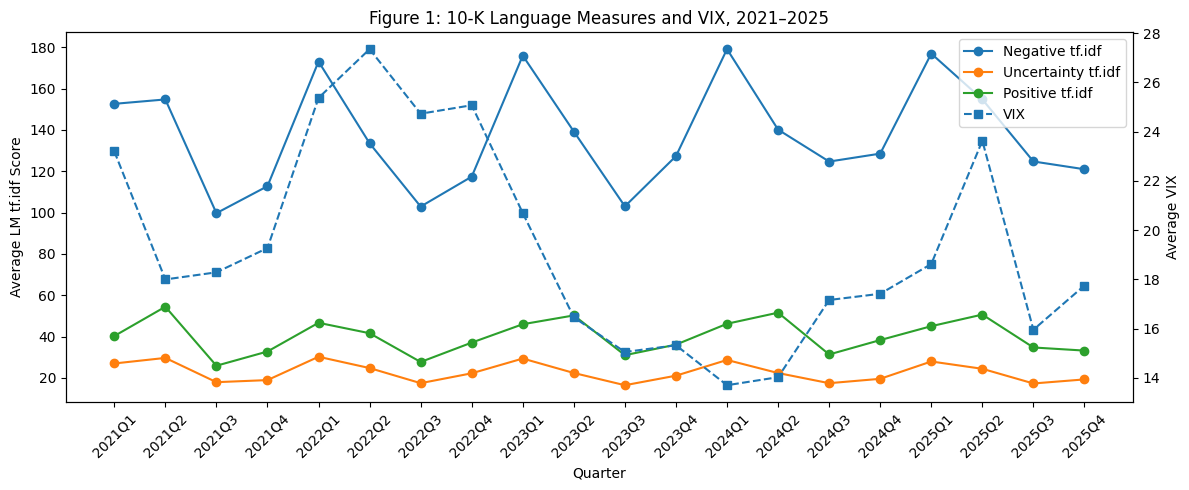

<Figure size 640x480 with 0 Axes>

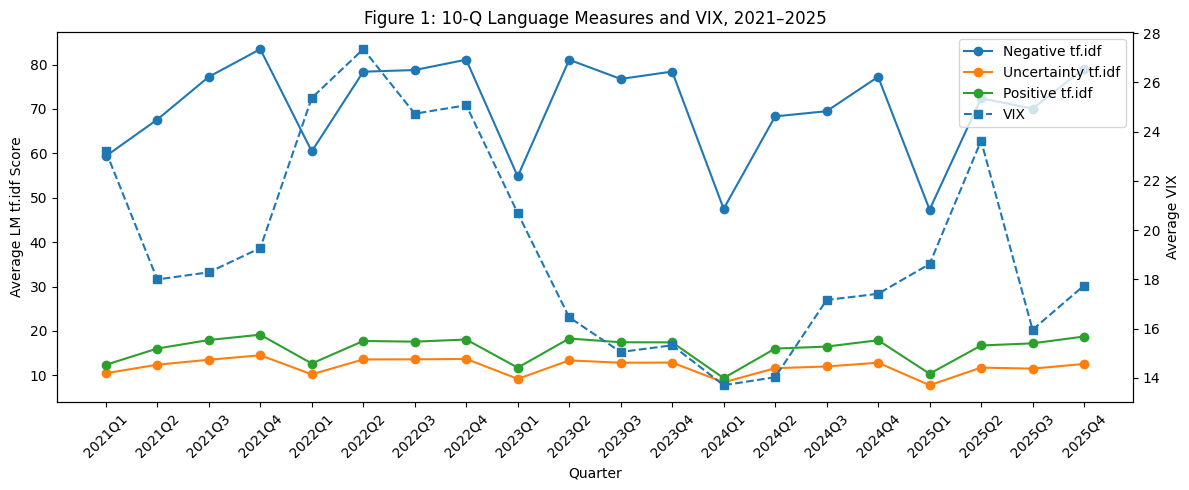

<Figure size 640x480 with 0 Axes>

In [167]:
vix = prices[["Date", "^VIX"]].copy()

vix["Date"] = pd.to_datetime(vix["Date"])

vix = vix[
    vix["Date"].dt.year.between(2021, 2025)
].copy()

vix["quarter"] = vix["Date"].dt.to_period("Q")

quarterly_vix = (
    vix.groupby("quarter")["^VIX"]
       .mean()
       .reset_index()
       .rename(columns={"^VIX": "VIX"})
)

figure1_df = quarterly.merge(
    quarterly_vix,
    on="quarter",
    how="left"
)

# Quarter labels
figure1_df["quarter_label"] = (
    figure1_df["quarter"].astype(str)
)

for form in ["10-K", "10-Q"]:

    plot_df = (
        figure1_df[
            figure1_df["form"] == form
        ]
        .sort_values("quarter")
        .copy()
    )

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # LM measures — left axis
    ax1.plot(
        plot_df["quarter_label"],
        plot_df["negative_tfidf"],
        marker="o",
        label="Negative tf.idf"
    )

    ax1.plot(
        plot_df["quarter_label"],
        plot_df["uncertainty_tfidf"],
        marker="o",
        label="Uncertainty tf.idf"
    )

    ax1.plot(
        plot_df["quarter_label"],
        plot_df["positive_tfidf"],
        marker="o",
        label="Positive tf.idf"
    )

    ax1.set_xlabel("Quarter")
    ax1.set_ylabel("Average LM tf.idf Score")

    ax1.tick_params(
        axis="x",
        rotation=45
    )

    # VIX — right axis
    ax2 = ax1.twinx()

    ax2.plot(
        plot_df["quarter_label"],
        plot_df["VIX"],
        linestyle="--",
        marker="s",
        label="VIX"
    )

    ax2.set_ylabel("Average VIX")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper right"
    )

    plt.title(
        f"Figure 1: {form} Language Measures and VIX, 2021–2025"
    )

    plt.tight_layout()
    plt.show()
    plt.savefig(f'outputs/figure1{form}.png')

### 3. Calculating an aggregate trend

In [152]:
import statsmodels.api as sm

def aggregate_trend_test(quarterly_df, form, measure):

    x = (
        quarterly_df[
            quarterly_df["form"] == form
        ]
        .sort_values("quarter")
        .copy()
    )

    # 2021Q1 = 0, ..., 2025Q4 = 19
    x["time"] = (
        (x["quarter"].dt.year - 2021) * 4
        + (x["quarter"].dt.quarter - 1)
    )

    X = sm.add_constant(x["time"])
    y = x[measure]

    # Newey-West / HAC standard errors
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    return {
        "Form": form,
        "Measure": measure,
        "Trend coefficient": model.params["time"],
        "Std. Error": model.bse["time"],
        "t-stat": model.tvalues["time"],
        "p-value": model.pvalues["time"],
        "N quarters": int(model.nobs)
    }


aggregate_results = []

for form in ["10-K", "10-Q"]:
    for measure in [
        "negative_prop",
        "negative_tfidf",
        "uncertainty_prop",
        "uncertainty_tfidf",
        "positive_prop",
        "positive_tfidf"
    ]:

        aggregate_results.append(
            aggregate_trend_test(
                quarterly,
                form,
                measure
            )
        )

aggregate_results = pd.DataFrame(aggregate_results)

display(
    aggregate_results.round(4)
)

,Form,Measure,Trend coefficient,Std. Error,t-stat,p-value,N quarters
0,10-K,negative_prop,0.0001,0.0000,4.6492,0.0000,20
1,10-K,negative_tfidf,0.2747,0.5376,0.5111,0.6093,20
2,10-K,uncertainty_prop,0.0001,0.0000,3.0551,0.0023,20
3,10-K,uncertainty_tfidf,-0.2181,0.0875,-2.4930,0.0127,20
4,10-K,positive_prop,0.0000,0.0000,1.3943,0.1632,20
5,10-K,positive_tfidf,0.0309,0.1871,0.1651,0.8689,20
6,10-Q,negative_prop,-0.0001,0.0000,-2.3483,0.0189,20
7,10-Q,negative_tfidf,-0.1470,0.2824,-0.5205,0.6027,20
8,10-Q,uncertainty_prop,-0.0001,0.0000,-3.7648,0.0002,20
9,10-Q,uncertainty_tfidf,-0.0787,0.0424,-1.8582,0.0631,20


### 4. Calculating trend by adjusting for firm baseline

In [153]:
import statsmodels.formula.api as smf

trend_df = scored_sample.copy()

trend_df["filing_date"] = pd.to_datetime(
    trend_df["filing_date"]
)

trend_df = trend_df[
    trend_df["filing_date"].dt.year.between(2021, 2025)
].copy()

trend_df["quarter"] = (
    trend_df["filing_date"]
    .dt.to_period("Q")
)

# 2021Q1 = 0, ..., 2025Q4 = 19
trend_df["time"] = (
    (trend_df["quarter"].dt.year - 2021) * 4
    + (trend_df["quarter"].dt.quarter - 1)
)


def within_firm_trend(data, form, measure):

    x = data[
        data["form"] == form
    ].copy()

    model = smf.ols(
        f"{measure} ~ time + C(ticker)",
        data=x
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": x["ticker"]
        }
    )

    return {
        "Form": form,
        "Measure": measure,
        "Trend coefficient": model.params["time"],
        "Std. Error": model.bse["time"],
        "t-stat": model.tvalues["time"],
        "p-value": model.pvalues["time"],
        "N filings": int(model.nobs),
        "N firms": x["ticker"].nunique()
    }


results = []

for form in ["10-K", "10-Q"]:
    for measure in [
        "negative_prop",
        "negative_tfidf",
        "uncertainty_prop",
        "uncertainty_tfidf",
        "positive_tfidf",
        "positive_prop"
    ]:

        results.append(
            within_firm_trend(
                trend_df,
                form,
                measure
            )
        )

within_firm_results = pd.DataFrame(results)

display(
    within_firm_results.round(4)
)

,Form,Measure,Trend coefficient,Std. Error,t-stat,p-value,N filings,N firms
0,10-K,negative_prop,0.0002,0.0000,8.0944,0.0000,384,88
1,10-K,negative_tfidf,0.9374,0.2286,4.1008,0.0000,384,88
2,10-K,uncertainty_prop,0.0001,0.0000,5.8122,0.0000,384,88
3,10-K,uncertainty_tfidf,-0.0861,0.0364,-2.3624,0.0182,384,88
4,10-K,positive_tfidf,0.1375,0.0668,2.0596,0.0394,384,88
5,10-K,positive_prop,0.0000,0.0000,3.2221,0.0013,384,88
6,10-Q,negative_prop,-0.0001,0.0000,-1.8396,0.0658,1158,90
7,10-Q,negative_tfidf,-0.4708,0.2906,-1.6200,0.1052,1158,90
8,10-Q,uncertainty_prop,-0.0001,0.0000,-2.4026,0.0163,1158,90
9,10-Q,uncertainty_tfidf,-0.1429,0.0351,-4.0765,0.0000,1158,90


### 5. Plotting the trend by adjusting for firm baseline

In [111]:
def plot_within_firm_trend(data, form, measure):

    x = data[data["form"] == form].copy()
    x["within_score"] = (
        x[measure]
        - x.groupby("ticker")[measure].transform("mean")
    )

    # Average the within-firm deviations by quarter
    plot_df = (
        x.groupby(["quarter", "time"])["within_score"]
        .mean()
        .reset_index()
        .sort_values("time")
    )

    model = smf.ols(
        f"{measure} ~ time + C(ticker)",
        data=x
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": x["ticker"]}
    )

    beta = model.params["time"]
    pval = model.pvalues["time"]

    intercept = (
        plot_df["within_score"].mean()
        - beta * plot_df["time"].mean()
    )

    plot_df["fitted_trend"] = (
        intercept + beta * plot_df["time"]
    )

    plt.figure(figsize=(11, 5))

    plt.plot(
        plot_df["quarter"].astype(str),
        plot_df["within_score"],
        marker="o",
        label="Average within-firm deviation"
    )

    plt.plot(
        plot_df["quarter"].astype(str),
        plot_df["fitted_trend"],
        linestyle="--",
        linewidth=2,
        label="Within-firm trend"
    )

    plt.axhline(
        0,
        linewidth=1,
        alpha=0.5
    )

    plt.xlabel("Quarter")
    plt.ylabel(f"{measure} deviation from firm mean")

    plt.title(
        f"{form}: Within-Firm Trend in {measure}\n"
        f"Trend = {beta:.3f} per quarter, p = {pval:.4f}"
    )

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

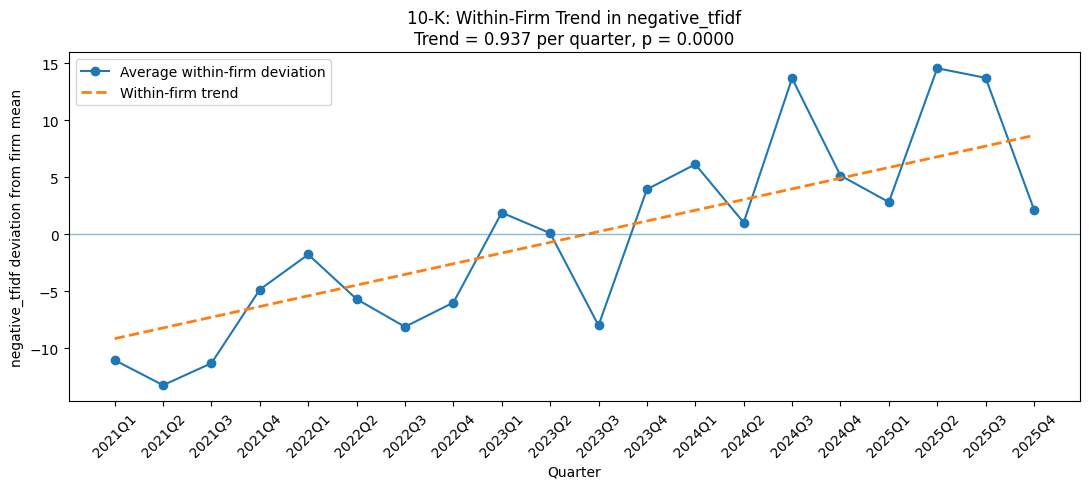

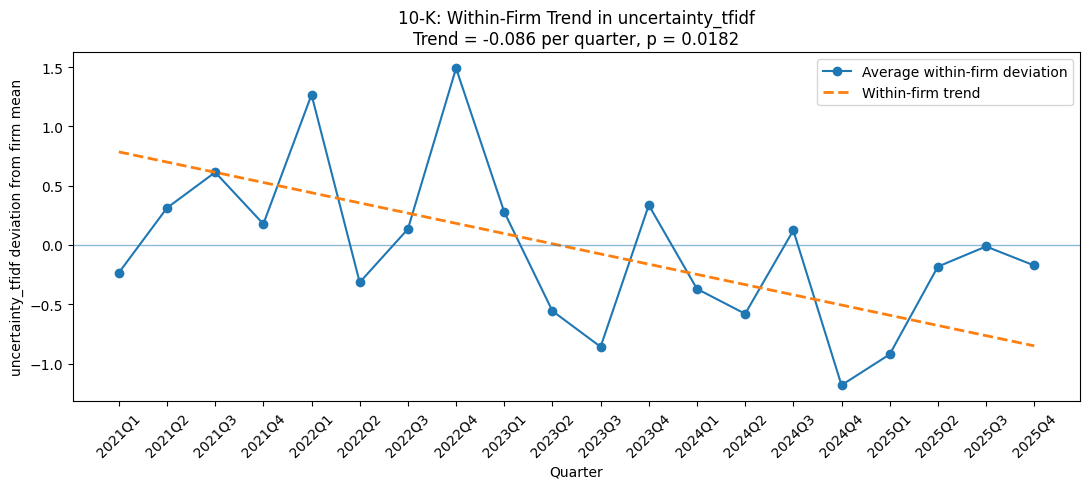

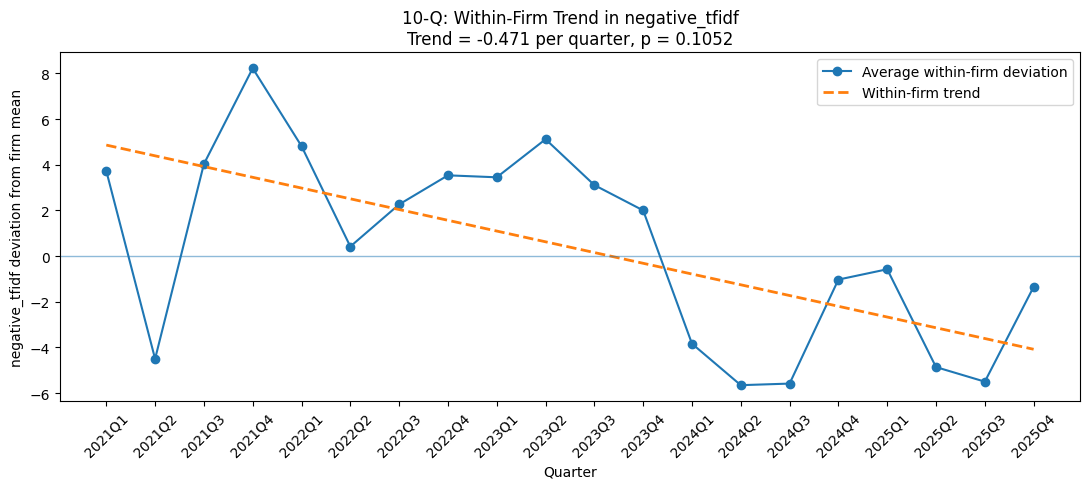

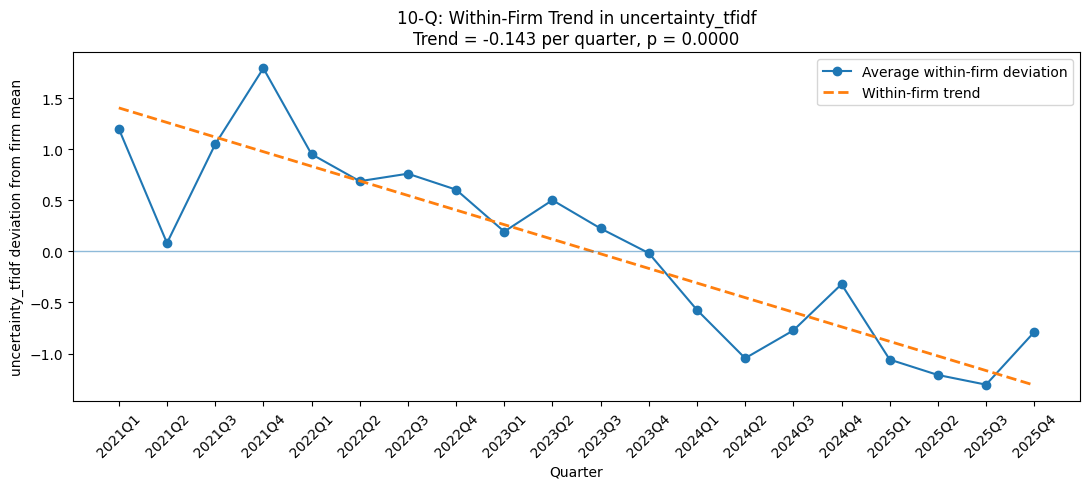

In [113]:
plot_within_firm_trend(trend_df, "10-K", "negative_tfidf")
plot_within_firm_trend(trend_df, "10-K", "uncertainty_tfidf")

plot_within_firm_trend(trend_df, "10-Q", "negative_tfidf")
plot_within_firm_trend(trend_df, "10-Q", "uncertainty_tfidf")

### 6. Plotting within-firm uncertainty trend against VIX

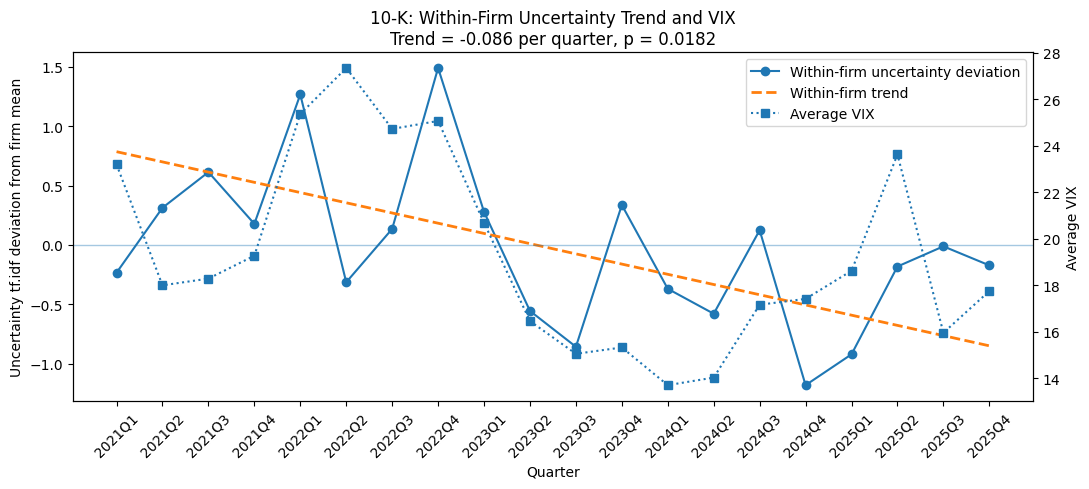

In [146]:
x = trend_df[
    trend_df["form"] == "10-K" #can change to 10-Q for that plot
].copy()

x["within_uncertainty"] = (
    x["uncertainty_tfidf"]
    - x.groupby("ticker")["uncertainty_tfidf"].transform("mean")
)

plot_df = (
    x.groupby(["quarter", "time"])["within_uncertainty"]
    .mean()
    .reset_index()
    .sort_values("time")
)


model = smf.ols(
    "uncertainty_tfidf ~ time + C(ticker)",
    data=x
).fit(
    cov_type="cluster",
    cov_kwds={"groups": x["ticker"]}
)

beta = model.params["time"]
pval = model.pvalues["time"]


intercept = (
    plot_df["within_uncertainty"].mean()
    - beta * plot_df["time"].mean()
)

plot_df["fitted_trend"] = (
    intercept + beta * plot_df["time"]
)

plot_df = plot_df.merge(
    quarterly_vix,
    on="quarter",
    how="left"
)

plot_df["quarter_label"] = plot_df["quarter"].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    plot_df["quarter_label"],
    plot_df["within_uncertainty"],
    marker="o",
    label="Within-firm uncertainty deviation"
)

ax1.plot(
    plot_df["quarter_label"],
    plot_df["fitted_trend"],
    linestyle="--",
    linewidth=2,
    label="Within-firm trend"
)

ax1.axhline(
    0,
    linewidth=1,
    alpha=0.4
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Uncertainty tf.idf deviation from firm mean")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["quarter_label"],
    plot_df["VIX"],
    marker="s",
    linestyle=":",
    label="Average VIX"
)

ax2.set_ylabel("Average VIX")

ax1.set_title(
    "10-K: Within-Firm Uncertainty Trend and VIX\n"
    f"Trend = {beta:.3f} per quarter, p = {pval:.4f}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.tight_layout()
plt.show()

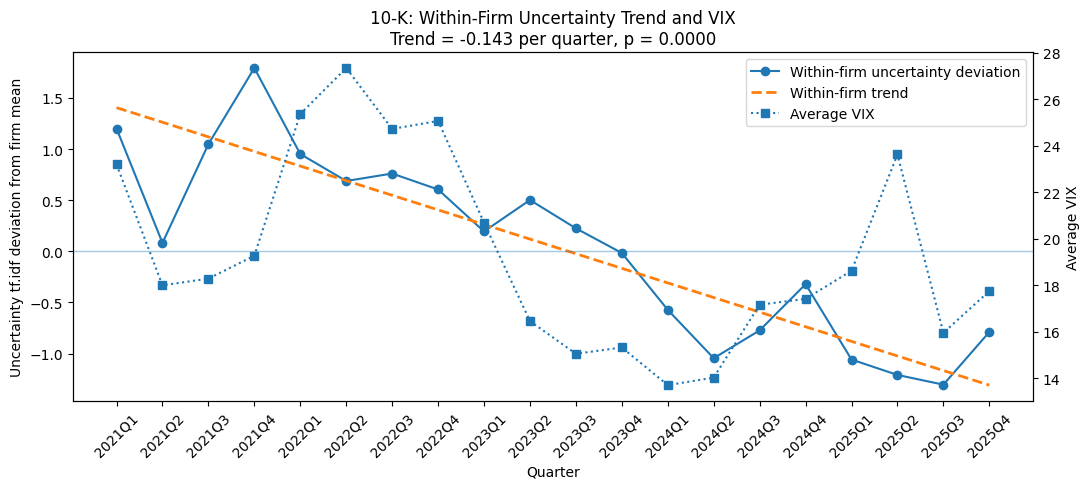

<Figure size 640x480 with 0 Axes>

In [168]:
x = trend_df[
    trend_df["form"] == "10-Q" #can change to 10-Q for that plot
].copy()

x["within_uncertainty"] = (
    x["uncertainty_tfidf"]
    - x.groupby("ticker")["uncertainty_tfidf"].transform("mean")
)

plot_df = (
    x.groupby(["quarter", "time"])["within_uncertainty"]
    .mean()
    .reset_index()
    .sort_values("time")
)


model = smf.ols(
    "uncertainty_tfidf ~ time + C(ticker)",
    data=x
).fit(
    cov_type="cluster",
    cov_kwds={"groups": x["ticker"]}
)

beta = model.params["time"]
pval = model.pvalues["time"]


intercept = (
    plot_df["within_uncertainty"].mean()
    - beta * plot_df["time"].mean()
)

plot_df["fitted_trend"] = (
    intercept + beta * plot_df["time"]
)

plot_df = plot_df.merge(
    quarterly_vix,
    on="quarter",
    how="left"
)

plot_df["quarter_label"] = plot_df["quarter"].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    plot_df["quarter_label"],
    plot_df["within_uncertainty"],
    marker="o",
    label="Within-firm uncertainty deviation"
)

ax1.plot(
    plot_df["quarter_label"],
    plot_df["fitted_trend"],
    linestyle="--",
    linewidth=2,
    label="Within-firm trend"
)

ax1.axhline(
    0,
    linewidth=1,
    alpha=0.4
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Uncertainty tf.idf deviation from firm mean")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["quarter_label"],
    plot_df["VIX"],
    marker="s",
    linestyle=":",
    label="Average VIX"
)

ax2.set_ylabel("Average VIX")

ax1.set_title(
    "10-K: Within-Firm Uncertainty Trend and VIX\n"
    f"Trend = {beta:.3f} per quarter, p = {pval:.4f}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.tight_layout()
plt.show()
plt.savefig('outputs/withinfirmtrend.png')

##

## Volatility Prediction by Uncertainty as a measure

In [119]:
analysis_sample = scored_sample.copy()

analysis_sample["day0"] = pd.to_datetime(
    analysis_sample["day0"]
)

prices["Date"] = pd.to_datetime(prices["Date"])


def calculate_volatility_windows(row):

    ticker = row["ticker"]
    day0 = row["day0"]

    if ticker not in prices.columns or pd.isna(day0):
        return pd.Series({
            "pre_vol": np.nan,
            "post_vol": np.nan,
            "n_pre_vol": 0,
            "n_post_vol": 0
        })

    p = (
        prices[["Date", ticker]]
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    day0_matches = p.index[p["Date"] == day0]

    if len(day0_matches) == 0:
        return pd.Series({
            "pre_vol": np.nan,
            "post_vol": np.nan,
            "n_pre_vol": 0,
            "n_post_vol": 0
        })

    i0 = day0_matches[0]

    # Daily close-to-close returns
    p["return"] = p[ticker].pct_change()

    # Pre-filing volatility: [-60, -6]

    pre_returns = p.loc[
        i0 - 60 : i0 - 6,
        "return"
    ].dropna()

    # Post-filing volatility: [+4, +63]

    post_returns = p.loc[
        i0 + 4 : i0 + 63,
        "return"
    ].dropna()

    # Require complete windows
    pre_vol = (
        pre_returns.std(ddof=1) * np.sqrt(252)
        if len(pre_returns) == 55
        else np.nan
    )

    post_vol = (
        post_returns.std(ddof=1) * np.sqrt(252)
        if len(post_returns) == 60
        else np.nan
    )

    return pd.Series({
        "pre_vol": pre_vol,
        "post_vol": post_vol,
        "n_pre_vol": len(pre_returns),
        "n_post_vol": len(post_returns)
    })


volatility_data = analysis_sample.apply(
    calculate_volatility_windows,
    axis=1
)

analysis_sample = pd.concat(
    [
        analysis_sample.reset_index(drop=True),
        volatility_data.reset_index(drop=True)
    ],
    axis=1
)

In [120]:
analysis_sample[
    [
        "ticker",
        "filing_date",
        "form",
        "uncertainty_tfidf",
        "pre_vol",
        "post_vol",
        "n_pre_vol",
        "n_post_vol"
    ]
].head(10)

,ticker,filing_date,form,uncertainty_tfidf,pre_vol,post_vol,n_pre_vol,n_post_vol
0,AIR,2021-03-23,10-Q,8.044230,0.443487,0.289742,55.0,60.0
1,AIR,2021-07-21,10-K,14.444424,0.294481,0.300730,55.0,60.0
2,AIR,2021-12-21,10-Q,6.161720,0.357443,0.315676,55.0,60.0
3,AIR,2022-03-22,10-Q,6.718028,0.286488,0.384802,55.0,60.0
4,AIR,2022-07-21,10-K,14.290449,0.401770,0.343615,55.0,60.0
5,AIR,2022-12-20,10-Q,2.149950,0.290537,0.288783,55.0,60.0
6,AIR,2023-03-21,10-Q,2.164577,0.255119,0.288864,55.0,60.0
7,AIR,2023-07-18,10-K,12.342605,0.301254,0.246434,55.0,60.0
8,AIR,2023-12-21,10-Q,2.403556,0.233994,0.308315,55.0,60.0
9,AIR,2024-03-21,10-Q,5.336687,0.288054,0.226974,55.0,60.0


In [ ]:
# Keep a common sample so the two columns are directly comparable
table5_df = analysis_sample[
    [
        "ticker",
        "post_vol",
        "pre_vol",
        "uncertainty_tfidf"
    ]
].dropna().copy()

#without pre-filing vol

model1 = smf.ols(
    "post_vol ~ uncertainty_tfidf",
    data=table5_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": table5_df["ticker"]}
)

#with pre-filing vol

model2 = smf.ols(
    "post_vol ~ uncertainty_tfidf + pre_vol",
    data=table5_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": table5_df["ticker"]}
)

In [123]:
table5 = pd.DataFrame({
    "Variable": [
        "Uncertainty tf.idf",
        "Pre-filing volatility"
    ],

    "Without Pre-Vol Coef.": [
        model1.params["uncertainty_tfidf"],
        None
    ],

    "Without Pre-Vol SE": [
        model1.bse["uncertainty_tfidf"],
        None
    ],

    "Without Pre-Vol p-value": [
        model1.pvalues["uncertainty_tfidf"],
        None
    ],

    "With Pre-Vol Coef.": [
        model2.params["uncertainty_tfidf"],
        model2.params["pre_vol"]
    ],

    "With Pre-Vol SE": [
        model2.bse["uncertainty_tfidf"],
        model2.bse["pre_vol"]
    ],

    "With Pre-Vol p-value": [
        model2.pvalues["uncertainty_tfidf"],
        model2.pvalues["pre_vol"]
    ]
})

display(table5.round(4))

print("\nModel statistics")
print(
    f"Without pre-vol: N={int(model1.nobs)}, "
    f"R²={model1.rsquared:.4f}"
)

print(
    f"With pre-vol:    N={int(model2.nobs)}, "
    f"R²={model2.rsquared:.4f}"
)

,Variable,Without Pre-Vol Coef.,Without Pre-Vol SE,Without Pre-Vol p-value,With Pre-Vol Coef.,With Pre-Vol SE,With Pre-Vol p-value
0,Uncertainty tf.idf,0.0072,0.0011,0.0,0.0046,0.0010,0.0000
1,Pre-filing volatility,NaN,NaN,NaN,0.3867,0.1158,0.0008



Model statistics
Without pre-vol: N=1542, R²=0.0802
With pre-vol:    N=1542, R²=0.3218


## Sentiment and Return Analysis

In [149]:
shares = pd.read_csv("data/prices/shares.csv")
print(shares.shape)
print(shares.columns.tolist())
display(shares.head(10))

(3544, 5)
['cik', 'accession', 'shares_outstanding', 'shares_as_of', 'shares_tag']


,cik,accession,shares_outstanding,shares_as_of,shares_tag
0,1750,0001104659-10-049632,39662816.0,2010-08-31,dei:EntityCommonStockSharesOutstanding
1,1750,0001104659-10-063683,39677152.0,2010-11-30,dei:EntityCommonStockSharesOutstanding
2,1750,0001104659-11-015691,39739031.0,2011-02-28,dei:EntityCommonStockSharesOutstanding
3,1750,0001047469-12-007300,40167070.0,2012-06-30,dei:EntityCommonStockSharesOutstanding
4,1750,0001104659-11-053058,40460631.0,2011-08-31,dei:EntityCommonStockSharesOutstanding
5,1750,0001104659-11-070822,40283131.0,2011-11-30,dei:EntityCommonStockSharesOutstanding
6,1750,0001104659-12-020988,40287771.0,2012-02-29,dei:EntityCommonStockSharesOutstanding
7,1750,0001047469-13-007797,39196369.0,2013-06-30,dei:EntityCommonStockSharesOutstanding
8,1750,0001104659-12-065381,39940227.0,2012-08-31,dei:EntityCommonStockSharesOutstanding
9,1750,0001104659-12-085900,39694849.0,2012-11-30,dei:EntityCommonStockSharesOutstanding


In [154]:
analysis_sample = scored_sample.copy()
prices["Date"] = pd.to_datetime(prices["Date"])

#filing period excess return - 4 day
def calc_filing_return(row):

    ticker = row["ticker"]
    day0 = pd.to_datetime(row["day0"])

    if ticker not in prices.columns:
        return np.nan

    stock = (
        prices[["Date", ticker]]
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    matches = stock.index[stock["Date"] == day0]

    if len(matches) == 0:
        return np.nan

    i0 = matches[0]

    if i0 < 1 or i0 + 3 >= len(stock):
        return np.nan

    start_date = stock.loc[i0 - 1, "Date"]
    end_date   = stock.loc[i0 + 3, "Date"]

    stock_return = (
        stock.loc[i0 + 3, ticker]
        / stock.loc[i0 - 1, ticker]
        - 1
    )

    spy = (
        prices[["Date", "SPY"]]
        .dropna()
        .set_index("Date")["SPY"]
    )

    if start_date not in spy.index or end_date not in spy.index:
        return np.nan

    spy_return = (
        spy.loc[end_date]
        / spy.loc[start_date]
        - 1
    )

    return stock_return - spy_return


analysis_sample["filing_excess_return"] = (
    analysis_sample.apply(calc_filing_return, axis=1)
)


#pre-filing excess return - 4 day
def calc_pre_excess_return(row):

    ticker = row["ticker"]
    day0 = pd.to_datetime(row["day0"])

    if ticker not in prices.columns:
        return np.nan

    stock = (
        prices[["Date", ticker]]
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    matches = stock.index[stock["Date"] == day0]

    if len(matches) == 0:
        return np.nan

    i0 = matches[0]

    if i0 < 61:
        return np.nan

    start_date = stock.loc[i0 - 61, "Date"]
    end_date   = stock.loc[i0 - 6, "Date"]

    stock_return = (
        stock.loc[i0 - 6, ticker]
        / stock.loc[i0 - 61, ticker]
        - 1
    )

    spy = (
        prices[["Date", "SPY"]]
        .dropna()
        .set_index("Date")["SPY"]
    )

    if start_date not in spy.index or end_date not in spy.index:
        return np.nan

    spy_return = (
        spy.loc[end_date]
        / spy.loc[start_date]
        - 1
    )

    return stock_return - spy_return


analysis_sample["pre_excess_return"] = (
    analysis_sample.apply(calc_pre_excess_return, axis=1)
)


#pre-filing vol - recalculated to be saved in analysis

def calc_pre_vol(row):

    ticker = row["ticker"]
    day0 = pd.to_datetime(row["day0"])

    if ticker not in prices.columns:
        return np.nan

    p = (
        prices[["Date", ticker]]
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    p["return"] = p[ticker].pct_change()

    matches = p.index[p["Date"] == day0]

    if len(matches) == 0:
        return np.nan

    i0 = matches[0]

    if i0 < 60:
        return np.nan

    pre_returns = (
        p.loc[i0 - 60:i0 - 6, "return"]
        .dropna()
    )

    if len(pre_returns) != 55:
        return np.nan

    return pre_returns.std() * np.sqrt(252)


analysis_sample["pre_vol"] = (
    analysis_sample.apply(calc_pre_vol, axis=1)
)


#adding reg controls

analysis_sample["is_10k"] = (
    analysis_sample["form"] == "10-K"
).astype(int)

analysis_sample["quarter"] = (
    pd.to_datetime(analysis_sample["filing_date"])
    .dt.to_period("Q")
    .astype(str)
)



sentiment_measures = [
    "negative_tfidf",
    "positive_tfidf",
    "negative_prop",
    "positive_prop"
]

results = []

for sentiment in sentiment_measures:

    cols = [
        "filing_excess_return",
        sentiment,
        "pre_excess_return",
        "pre_vol",
        "is_10k",
        "ticker",
        "quarter"
    ]

    reg = analysis_sample[cols].dropna().copy()

    formula = (
        f"filing_excess_return ~ {sentiment}"
        " + pre_excess_return"
        " + pre_vol"
        " + is_10k"
        " + C(ticker)"
        " + C(quarter)"
    )

    model = smf.ols(
        formula,
        data=reg
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": reg["ticker"]}
    )

    results.append({
        "Sentiment": sentiment,
        "Coef": model.params[sentiment],
        "SE": model.bse[sentiment],
        "t": model.tvalues[sentiment],
        "p": model.pvalues[sentiment],
        "N": int(model.nobs),
        "R2": model.rsquared
    })

table6 = pd.DataFrame(results)

display(
    table6.style.format({
        "Coef": "{:.6f}",
        "SE": "{:.6f}",
        "t": "{:.3f}",
        "p": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Sentiment,Coef,SE,t,p,N,R2
0,negative_tfidf,-0.000156,0.000101,-1.540,0.1235,1542,0.0822
1,positive_tfidf,-0.000779,0.000487,-1.599,0.1098,1542,0.0823
2,negative_prop,-1.108540,0.561849,-1.973,0.0485,1542,0.0820
3,positive_prop,-2.670295,3.530356,-0.756,0.4494,1542,0.0803


In [155]:
table6.to_csv('outputs/table6.csv')

In [159]:
table2_clean.to_csv('outputs/table2.csv')

In [160]:
table3_report.to_csv('outputs/table3.csv')

In [161]:
aggregate_results.to_csv('outputs/table4agg.csv')

In [162]:
within_firm_results.to_csv(
    'outputs/table4withinfirm.csv'
)

In [164]:
table5_df.to_csv('outputs/table5.csv')

In [166]:
table6.to_csv('outputs/table6.csv')
